# Pushshift Transformer Model: BERT

This notebook implements the BERT-based transformer model for the Pushshift Reddit pipeline under the unified project structure.

It is designed to:
- load the fixed Pushshift train/validation/test splits from `Code/artifacts/pushshift/splits/`
- fine-tune a three-class BERT classifier for Reddit sentiment classification
- save reusable experiment artifacts for later comparison with TF-IDF and LSTM models
- export prediction files, evaluation figures, and configuration outputs for thesis writing
- produce probability-based outputs that can support later happiness index construction

## 0. Verify required packages

This section checks the main dependencies used in the BERT experiment.
The notebook installs missing packages into the active VSCode kernel when needed.

In [1]:
import importlib
import subprocess
import sys

def install_if_missing(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
        print(f"✅ {package_name} already installed")
    except ImportError:
        print(f"⬇️ Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scikit-learn", "sklearn"),
    ("torch", "torch"),
    ("transformers", "transformers"),
    ("datasets", "datasets"),
    ("accelerate", "accelerate"),
]

for package_name, import_name in required_packages:
    install_if_missing(package_name, import_name)

print("Python executable:", sys.executable)

✅ numpy already installed
✅ pandas already installed
✅ matplotlib already installed
✅ seaborn already installed
✅ scikit-learn already installed
✅ torch already installed
✅ transformers already installed
✅ datasets already installed
✅ accelerate already installed
Python executable: d:\Anaconda\envs\happiness-nlp\python.exe


## 1. Setup and unified paths

Paths are resolved relative to the current VSCode notebook location.
All outputs follow the shared `artifacts/pushshift/` layout.

In [2]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, f1_score
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROJECT_ROOT = CODE_DIR

DATASET_DIR = PROJECT_ROOT / "dataset" / "pushshift"
ARTIFACT_ROOT = CODE_DIR / "artifacts"
DATASET_ARTIFACT_DIR = ARTIFACT_ROOT / "pushshift"

SPLIT_DIR = DATASET_ARTIFACT_DIR / "splits"
PRED_DIR = DATASET_ARTIFACT_DIR / "predictions"
MODEL_DIR = DATASET_ARTIFACT_DIR / "models"
CONFIG_DIR = DATASET_ARTIFACT_DIR / "config"
FIG_DIR = DATASET_ARTIFACT_DIR / "figures"
RESULT_DIR = DATASET_ARTIFACT_DIR / "results"
RESOURCE_DIR = DATASET_ARTIFACT_DIR / "resources"

for folder in [SPLIT_DIR, PRED_DIR, MODEL_DIR, CONFIG_DIR, FIG_DIR, RESULT_DIR, RESOURCE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

CSV_PATH = DATASET_DIR / "reddit_vader_dataset.csv"
TRAIN_PATH = SPLIT_DIR / "train_60.csv"
VAL_PATH = SPLIT_DIR / "val_10.csv"
TEST_PATH = SPLIT_DIR / "test_30.csv"

RANDOM_STATE = 42
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128
NUM_LABELS = 3

# Keep these as None for the formal run.
# For quick debugging, use smaller values such as 5000 and 2000.
SAMPLE_TRAIN_SIZE = None
SAMPLE_EVAL_SIZE = None

TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2

LABEL_MAP = {0: "Negative", 1: "Neutral", 2: "Positive"}
ID2LABEL = {i: LABEL_MAP[i] for i in range(NUM_LABELS)}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CSV_PATH:", CSV_PATH)
print("Split directory:", SPLIT_DIR)
sns.set_theme(style="whitegrid")

Using device: cuda
CSV_PATH: e:\桌面\Graduation_Thesis\Dataset\pushshift\reddit_vader_dataset.csv
Split directory: e:\桌面\Graduation_Thesis\Code\artifacts\pushshift\splits


## 2. Load dataset splits

The BERT model uses the same fixed splits as TF-IDF and LSTM.
If these files do not exist, the notebook creates stratified 60/10/30 splits from the processed Reddit dataset.

In [3]:
from sklearn.model_selection import train_test_split

if TRAIN_PATH.exists() and VAL_PATH.exists() and TEST_PATH.exists():
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
    test_df = pd.read_csv(TEST_PATH)
    print("Loaded existing fixed splits.")
else:
    if not CSV_PATH.exists():
        raise FileNotFoundError(f"Missing dataset file: {CSV_PATH}")

    df = pd.read_csv(CSV_PATH)
    df = df.dropna(subset=["text", "label"]).copy()
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"] != ""]
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

    train_df, temp_df = train_test_split(df, test_size=0.4, random_state=RANDOM_STATE, stratify=df["label"])
    val_df, test_df = train_test_split(temp_df, test_size=0.75, random_state=RANDOM_STATE, stratify=temp_df["label"])

    train_df.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
    val_df.to_csv(VAL_PATH, index=False, encoding="utf-8")
    test_df.to_csv(TEST_PATH, index=False, encoding="utf-8")
    print("Created and saved fixed splits.")

print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))

Loaded existing fixed splits.
Train / Val / Test sizes: 16931 2822 8466


In [4]:
for split_name, split_df in {"Train": train_df, "Validation": val_df, "Test": test_df}.items():
    print(f"\n{split_name} label distribution:")
    print(split_df["label"].value_counts().sort_index())


Train label distribution:
label
0.0    4485
1.0    4207
2.0    8239
Name: count, dtype: int64

Validation label distribution:
label
0.0     748
1.0     701
2.0    1373
Name: count, dtype: int64

Test label distribution:
label
0.0    2243
1.0    2103
2.0    4120
Name: count, dtype: int64


## 3. Optional sampling for faster debugging

This section allows smaller experimental runs without changing the fixed split files.
For the final thesis run, keep the sampling variables as `None`.

In [5]:
def optional_sample(df, n, label_col="label"):
    if n is None or n >= len(df):
        return df.reset_index(drop=True)
    return (
        df.groupby(label_col, group_keys=False)
        .apply(lambda x: x.sample(min(len(x), max(1, int(n * len(x) / len(df)))), random_state=RANDOM_STATE))
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

train_run_df = optional_sample(train_df, SAMPLE_TRAIN_SIZE)
val_run_df = optional_sample(val_df, SAMPLE_EVAL_SIZE)
test_run_df = optional_sample(test_df, SAMPLE_EVAL_SIZE)

print("Run train size:", len(train_run_df))
print("Run val size:", len(val_run_df))
print("Run test size:", len(test_run_df))

Run train size: 16931
Run val size: 2822
Run test size: 8466


## 4. Prepare Hugging Face datasets

The Reddit text and labels are converted into Hugging Face `Dataset` objects.
Only the text and label columns are required for fine-tuning.

In [6]:
def prepare_hf_df(df):
    out = df[["text", "label"]].copy()
    out["text"] = out["text"].astype(str)
    out["label"] = out["label"].astype(int)
    return out

hf_train = Dataset.from_pandas(prepare_hf_df(train_run_df), preserve_index=False)
hf_val = Dataset.from_pandas(prepare_hf_df(val_run_df), preserve_index=False)
hf_test = Dataset.from_pandas(prepare_hf_df(test_run_df), preserve_index=False)

print(hf_train)
print(hf_val)
print(hf_test)

Dataset({
    features: ['text', 'label'],
    num_rows: 16931
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2822
})
Dataset({
    features: ['text', 'label'],
    num_rows: 8466
})


## 5. Tokenize the text inputs

The BERT tokenizer converts Reddit comments into token IDs and attention masks.
A maximum length of 128 is used to balance context coverage and training cost.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)

hf_train_tok = hf_train.map(tokenize_batch, batched=True)
hf_val_tok = hf_val.map(tokenize_batch, batched=True)
hf_test_tok = hf_test.map(tokenize_batch, batched=True)

hf_train_tok = hf_train_tok.remove_columns(["text"])
hf_val_tok = hf_val_tok.remove_columns(["text"])
hf_test_tok = hf_test_tok.remove_columns(["text"])

hf_train_tok.set_format("torch")
hf_val_tok.set_format("torch")
hf_test_tok.set_format("torch")

print(hf_train_tok)

Map:   0%|          | 0/16931 [00:00<?, ? examples/s]

Map:   0%|          | 0/2822 [00:00<?, ? examples/s]

Map:   0%|          | 0/8466 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 16931
})


## 6. Build the BERT classifier

A pretrained `bert-base-uncased` encoder is fine-tuned with a three-class classification head.
This model can capture contextual meaning more effectively than TF-IDF and LSTM baselines.

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

model.to(device)
print("Model loaded:", MODEL_NAME)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: bert-base-uncased


## 7. Define metrics and training arguments

The training process reports accuracy, macro F1, weighted F1, precision, and recall.
Macro F1 is especially useful because the label distribution is not perfectly balanced.

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
    }

bert_output_dir = MODEL_DIR / "pushshift_bert_3class"

training_args = TrainingArguments(
    output_dir=str(bert_output_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=50,
    report_to="none",
    seed=RANDOM_STATE,
)

## 8. Build the Trainer

This section combines the model, datasets, tokenizer, and callbacks into a Hugging Face Trainer workflow.

In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_train_tok,
    eval_dataset=hf_val_tok,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

## 9. Fine-tune BERT

The model is fine-tuned on the fixed Pushshift training split.
Early stopping is used to reduce overfitting and unnecessary training time.

In [11]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.473912,0.400638,0.861446,0.866970,0.840393,0.851606,0.863444,0.861446,0.860493
2,0.308946,0.405850,0.879164,0.879432,0.866733,0.872449,0.880275,0.879164,0.879167
3,0.204817,0.533274,0.881290,0.879763,0.870129,0.874297,0.882899,0.881290,0.881577


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=6351, training_loss=0.3457962117855745, metrics={'train_runtime': 1029.5952, 'train_samples_per_second': 49.333, 'train_steps_per_second': 6.168, 'total_flos': 3341079956664576.0, 'train_loss': 0.3457962117855745, 'epoch': 3.0})

## 10. Export training history and learning curves
The training log history is exported to CSV for reporting and plotting.
This makes the BERT experiment easier to compare with the TF-IDF and LSTM baselines.

Saved log history: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\resources\bert_training_log_history.csv


,epoch,loss,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted
121,2.834199,0.123390,NaN,NaN,NaN,NaN
122,2.857818,0.088571,NaN,NaN,NaN,NaN
123,2.881436,0.220677,NaN,NaN,NaN,NaN
124,2.905054,0.209135,NaN,NaN,NaN,NaN
125,2.928673,0.237199,NaN,NaN,NaN,NaN
126,2.952291,0.170279,NaN,NaN,NaN,NaN
127,2.975909,0.202895,NaN,NaN,NaN,NaN
128,2.999528,0.204817,NaN,NaN,NaN,NaN
129,3.000000,NaN,0.533274,0.88129,0.874297,0.881577
130,3.000000,NaN,NaN,NaN,NaN,NaN


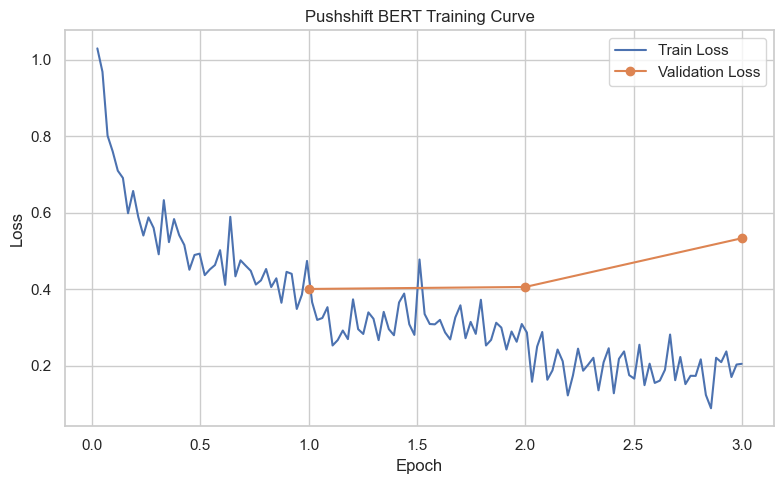

Saved training curve: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\figures\bert_training_curve.png


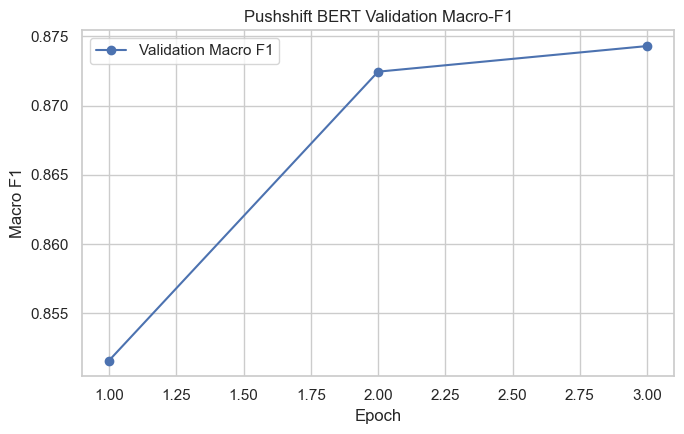

Saved validation macro-F1 curve: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\figures\bert_validation_macro_f1.png


In [18]:
log_history = pd.DataFrame(trainer.state.log_history)
log_path = RESOURCE_DIR / "bert_training_log_history.csv"
log_history.to_csv(log_path, index=False, encoding="utf-8")

display_cols = [
    c for c in [
        "epoch",
        "loss",
        "eval_loss",
        "eval_accuracy",
        "eval_f1_macro",
        "eval_f1_weighted"
    ]
    if c in log_history.columns
]

print("Saved log history:", log_path.resolve())
display(log_history[display_cols].tail(10) if display_cols else log_history.tail(10))

# =========================================================
# 1) BERT training curve: Train Loss + Validation Loss
# =========================================================
plot_df = log_history.copy()

if "epoch" in plot_df.columns and ("loss" in plot_df.columns or "eval_loss" in plot_df.columns):
    plt.figure(figsize=(8, 5))

    if "loss" in plot_df.columns:
        train_curve = plot_df.dropna(subset=["loss", "epoch"])[["epoch", "loss"]]
        if not train_curve.empty:
            plt.plot(
                train_curve["epoch"],
                train_curve["loss"],
                label="Train Loss"
            )

    if "eval_loss" in plot_df.columns:
        eval_curve = plot_df.dropna(subset=["eval_loss", "epoch"])[["epoch", "eval_loss"]]
        if not eval_curve.empty:
            plt.plot(
                eval_curve["epoch"],
                eval_curve["eval_loss"],
                marker="o",
                label="Validation Loss"
            )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Pushshift BERT Training Curve")
    plt.legend()
    plt.tight_layout()

    training_curve_path = FIG_DIR / "bert_training_curve.png"
    plt.savefig(training_curve_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved training curve:", training_curve_path.resolve())
else:
    print("Training history did not contain plottable loss values.")

# =========================================================
# 2) Validation-only metrics
# =========================================================
eval_cols = [c for c in log_history.columns if c.startswith("eval_")]
eval_rows = log_history.dropna(subset=eval_cols, how="all").copy() if eval_cols else pd.DataFrame()

if not eval_rows.empty:
    # === Validation macro-F1 curve ===
    if "eval_f1_macro" in eval_rows.columns:
        plt.figure(figsize=(7, 4.5))
        plt.plot(
            eval_rows["epoch"],
            eval_rows["eval_f1_macro"],
            marker="o",
            label="Validation Macro F1"
        )
        plt.xlabel("Epoch")
        plt.ylabel("Macro F1")
        plt.title("Pushshift BERT Validation Macro-F1")
        plt.legend()
        plt.tight_layout()

        f1_curve_path = FIG_DIR / "bert_validation_macro_f1.png"
        plt.savefig(f1_curve_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved validation macro-F1 curve:", f1_curve_path.resolve())

else:
    print("No evaluation rows found in log history.")
    print("Available log columns:", log_history.columns.tolist())

## 11. Evaluate on the test set

The best checkpoint is evaluated on the held-out test set.
The resulting metrics provide the main transformer result for model comparison.

In [13]:
test_output = trainer.predict(hf_test_tok)

test_logits = test_output.predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
test_preds = np.argmax(test_probs, axis=1)
test_labels = test_output.label_ids

test_accuracy = accuracy_score(test_labels, test_preds)
test_macro_f1 = f1_score(test_labels, test_preds, average="macro")

print("Test accuracy:", round(test_accuracy, 4))
print("Test macro F1:", round(test_macro_f1, 4))

print("\nClassification report:")
print(classification_report(test_labels, test_preds, digits=4, target_names=[LABEL_MAP[i] for i in range(NUM_LABELS)]))

Test accuracy: 0.8815
Test macro F1: 0.8771

Classification report:
              precision    recall  f1-score   support

    Negative     0.8060    0.8649    0.8344      2243
     Neutral     0.9322    0.8626    0.8960      2103
    Positive     0.9018    0.9002    0.9010      4120

    accuracy                         0.8815      8466
   macro avg     0.8800    0.8759    0.8771      8466
weighted avg     0.8839    0.8815    0.8821      8466



## 12. Confusion matrix

The confusion matrix shows how the BERT model handles negative, neutral, and positive comments.
It is saved as a figure for later thesis writing.

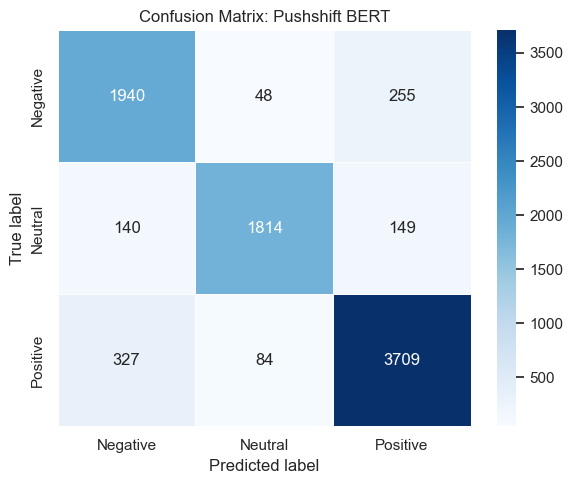

Saved confusion matrix figure: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\figures\bert_confusion_matrix.png


In [14]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=[LABEL_MAP[i] for i in range(NUM_LABELS)],
    yticklabels=[LABEL_MAP[i] for i in range(NUM_LABELS)],
    linewidths=0.5,
    linecolor="white",
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: Pushshift BERT")
plt.tight_layout()

cm_path = FIG_DIR / "bert_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix figure:", cm_path.resolve())

## 13. Construct a Temporal Happiness Index

The BERT predictions are converted into comment-level happiness scores and then aggregated into overall, temporal, and subreddit-level happiness index outputs.

For the three-class Pushshift setting, negative, neutral, and positive predictions are mapped to -1, 0, and +1. A probability-based score is also computed as `prob_positive - prob_negative`. The raw index is kept in `[-1, 1]`, and a 0-100 version is exported for easier comparison and visualisation.


In [15]:
label_to_score = {0: -1, 1: 0, 2: 1}

pred_df = test_run_df.copy().reset_index(drop=True)
pred_df["y_true"] = test_labels.astype(int)
pred_df["pred_label"] = test_preds.astype(int)
pred_df["prob_negative"] = test_probs[:, 0].astype(float)
pred_df["prob_neutral"] = test_probs[:, 1].astype(float)
pred_df["prob_positive"] = test_probs[:, 2].astype(float)
pred_df["true_label_name"] = pred_df["y_true"].map(LABEL_MAP)
pred_df["pred_label_name"] = pred_df["pred_label"].map(LABEL_MAP)

pred_df["score_label_3class"] = pred_df["pred_label"].map(label_to_score)
pred_df["score_prob_continuous"] = pred_df["prob_positive"] - pred_df["prob_negative"]

hi_df = pred_df.copy()

if "created_utc" not in hi_df.columns:
    raise ValueError("`created_utc` is required to construct the temporal happiness index for Pushshift.")

# Parse timestamps robustly and keep the UTC-aware timestamp for traceability.
if pd.api.types.is_numeric_dtype(hi_df["created_utc"]):
    hi_df["created_dt"] = pd.to_datetime(hi_df["created_utc"], unit="s", utc=True, errors="coerce")
else:
    hi_df["created_dt"] = pd.to_datetime(hi_df["created_utc"], utc=True, errors="coerce")

hi_df = hi_df.dropna(subset=["created_dt"]).copy()
hi_df = hi_df.sort_values("created_dt").reset_index(drop=True)

if hi_df.empty:
    raise ValueError("No valid timestamps were available after parsing `created_utc`.")

# Choose temporal window automatically.
time_span_days = (hi_df["created_dt"].max() - hi_df["created_dt"].min()).days

# Period-based grouping does not keep timezone metadata, so use a timezone-naive
# copy only for the aggregation key while retaining `created_dt` as UTC-aware.
created_dt_naive = hi_df["created_dt"].dt.tz_localize(None)

if time_span_days >= 90:
    temporal_window = "month"
    hi_df["time_window"] = created_dt_naive.dt.to_period("M").astype(str)
elif time_span_days >= 28:
    temporal_window = "week"
    hi_df["time_window"] = created_dt_naive.dt.to_period("W-MON").astype(str)
else:
    temporal_window = "day"
    hi_df["time_window"] = created_dt_naive.dt.strftime("%Y-%m-%d")


def ratio(series, value):
    return float((series == value).mean())


def safe_mean(series):
    s = pd.to_numeric(series, errors="coerce")
    return float(s.mean()) if s.notna().any() else np.nan


overall_summary = {
    "dataset": "pushshift",
    "model": "bert_base_uncased",
    "index_variant": "overall_temporal_ready",
    "sample_size": int(len(hi_df)),
    "time_span_days": int(time_span_days),
    "temporal_window": temporal_window,
    "n_time_windows": int(hi_df["time_window"].nunique()),
    "negative_ratio": ratio(hi_df["pred_label"], 0),
    "neutral_ratio": ratio(hi_df["pred_label"], 1),
    "positive_ratio": ratio(hi_df["pred_label"], 2),
    "mean_prob_negative": safe_mean(hi_df["prob_negative"]),
    "mean_prob_neutral": safe_mean(hi_df["prob_neutral"]),
    "mean_prob_positive": safe_mean(hi_df["prob_positive"]),
    "hi_label_raw": safe_mean(hi_df["score_label_3class"]),
    "hi_label_100": float(50 * (safe_mean(hi_df["score_label_3class"]) + 1)),
    "hi_prob_raw": safe_mean(hi_df["score_prob_continuous"]),
    "hi_prob_100": float(50 * (safe_mean(hi_df["score_prob_continuous"]) + 1)),
}

temporal_rows = []

for time_window, g in hi_df.groupby("time_window", sort=False):
    window_start_dt = g["created_dt"].min()

    row = {
        "time_window": time_window,
        "time_window_start": window_start_dt.strftime("%Y-%m-%d"),
        "time_window_start_utc": window_start_dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "sample_size": int(len(g)),
        "negative_ratio": ratio(g["pred_label"], 0),
        "neutral_ratio": ratio(g["pred_label"], 1),
        "positive_ratio": ratio(g["pred_label"], 2),
        "mean_prob_negative": safe_mean(g["prob_negative"]),
        "mean_prob_neutral": safe_mean(g["prob_neutral"]),
        "mean_prob_positive": safe_mean(g["prob_positive"]),
        "hi_label_raw": safe_mean(g["score_label_3class"]),
        "hi_label_100": float(50 * (safe_mean(g["score_label_3class"]) + 1)),
        "hi_prob_raw": safe_mean(g["score_prob_continuous"]),
        "hi_prob_100": float(50 * (safe_mean(g["score_prob_continuous"]) + 1)),
    }
    temporal_rows.append(row)

temporal_hi_df = (
    pd.DataFrame(temporal_rows)
    .sort_values("time_window_start")
    .reset_index(drop=True)
)

subreddit_temporal_hi_df = pd.DataFrame()

if "subreddit" in hi_df.columns:
    subreddit_rows = []

    for (subreddit, time_window), g in hi_df.groupby(["subreddit", "time_window"], sort=False):
        window_start_dt = g["created_dt"].min()

        row = {
            "subreddit": subreddit,
            "time_window": time_window,
            "time_window_start": window_start_dt.strftime("%Y-%m-%d"),
            "time_window_start_utc": window_start_dt.strftime("%Y-%m-%dT%H:%M:%SZ"),
            "sample_size": int(len(g)),
            "negative_ratio": ratio(g["pred_label"], 0),
            "neutral_ratio": ratio(g["pred_label"], 1),
            "positive_ratio": ratio(g["pred_label"], 2),
            "hi_label_raw": safe_mean(g["score_label_3class"]),
            "hi_label_100": float(50 * (safe_mean(g["score_label_3class"]) + 1)),
            "hi_prob_raw": safe_mean(g["score_prob_continuous"]),
            "hi_prob_100": float(50 * (safe_mean(g["score_prob_continuous"]) + 1)),
        }
        subreddit_rows.append(row)

    subreddit_temporal_hi_df = (
        pd.DataFrame(subreddit_rows)
        .sort_values(["subreddit", "time_window_start"])
        .reset_index(drop=True)
    )

overall_summary_df = pd.DataFrame([overall_summary])

print("Selected temporal window:", temporal_window)
print("Time span (days):", time_span_days)
print("Number of windows:", hi_df["time_window"].nunique())

print("\nOverall happiness index summary:")
display(overall_summary_df)

print("\nTemporal happiness index preview:")
display(temporal_hi_df.head())

if not subreddit_temporal_hi_df.empty:
    print("\nSubreddit-level temporal happiness index preview:")
    display(subreddit_temporal_hi_df.head())


Selected temporal window: month
Time span (days): 335
Number of windows: 12

Overall happiness index summary:


,dataset,model,index_variant,sample_size,time_span_days,temporal_window,n_time_windows,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,pushshift,bert_base_uncased,overall_temporal_ready,8466,335,month,12,0.284314,0.229861,0.485826,0.280929,0.233467,0.485604,0.201512,60.075597,0.204675,60.233747



Temporal happiness index preview:


,time_window,time_window_start,time_window_start_utc,sample_size,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,2022-01,2022-01-01,2022-01-01T00:00:00Z,692,0.278902,0.202312,0.518786,0.275047,0.203365,0.521588,0.239884,61.994220,0.246542,62.327085
1,2022-02,2022-02-01,2022-02-01T00:00:00Z,699,0.280401,0.190272,0.529328,0.274852,0.198090,0.527058,0.248927,62.446352,0.252207,62.610326
2,2022-03,2022-03-01,2022-03-01T00:00:00Z,735,0.300680,0.234014,0.465306,0.297845,0.236452,0.465703,0.164626,58.231293,0.167857,58.392859
3,2022-04,2022-04-01,2022-04-01T00:00:00Z,684,0.280702,0.244152,0.475146,0.277407,0.246969,0.475625,0.194444,59.722222,0.198218,59.910879
4,2022-05,2022-05-01,2022-05-01T00:00:00Z,695,0.306475,0.247482,0.446043,0.298696,0.252986,0.448319,0.139568,56.978417,0.149623,57.481156



Subreddit-level temporal happiness index preview:


,subreddit,time_window,time_window_start,time_window_start_utc,sample_size,negative_ratio,neutral_ratio,positive_ratio,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,AskReddit,2022-01,2022-01-01,2022-01-01T00:00:00Z,221,0.316742,0.380090,0.303167,-0.013575,49.321267,0.002213,50.110662
1,AskReddit,2022-02,2022-02-01,2022-02-01T00:00:00Z,241,0.307054,0.319502,0.373444,0.066390,53.319502,0.063716,53.185782
2,AskReddit,2022-03,2022-03-01,2022-03-01T00:00:00Z,229,0.240175,0.362445,0.397380,0.157205,57.860262,0.157395,57.869730
3,AskReddit,2022-04,2022-04-01,2022-04-01T00:00:00Z,222,0.288288,0.405405,0.306306,0.018018,50.900901,0.025033,51.251665
4,AskReddit,2022-05,2022-05-01,2022-05-01T00:00:00Z,221,0.343891,0.330317,0.325792,-0.018100,49.095023,-0.006094,49.695304


## 14. Export experiment artifacts

This section saves the fine-tuned model, tokenizer, test predictions, configuration, and happiness index outputs.

The outputs follow the same artifact layout as the TF-IDF and LSTM experiments, including `predictions/`, `models/`, `config/`, `figures/`, and `results/`.


In [16]:
trainer.save_model(str(bert_output_dir))
tokenizer.save_pretrained(str(bert_output_dir))

pred_path = PRED_DIR / "pred_test_bert_3class.csv"
pred_df.to_csv(pred_path, index=False, encoding="utf-8")

model_config = {
    "model_name": MODEL_NAME,
    "model_alias": "bert_base_uncased",
    "dataset": "pushshift",
    "task": "three_class_sentiment",
    "random_state": RANDOM_STATE,
    "max_length": MAX_LENGTH,
    "num_labels": NUM_LABELS,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "best_checkpoint_metric": "f1_macro",
    "sample_train_size": SAMPLE_TRAIN_SIZE,
    "sample_eval_size": SAMPLE_EVAL_SIZE,
    "run_train_size": int(len(train_run_df)),
    "run_val_size": int(len(val_run_df)),
    "run_test_size": int(len(test_run_df)),
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_macro_f1),
}

config_path = CONFIG_DIR / "bert_model_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=2)

overall_summary_path = RESULT_DIR / "bert_happiness_index_overall.json"
with open(overall_summary_path, "w", encoding="utf-8") as f:
    json.dump(overall_summary, f, ensure_ascii=False, indent=2)

overall_summary_csv_path = RESULT_DIR / "bert_happiness_index_summary.csv"
overall_summary_df.to_csv(overall_summary_csv_path, index=False, encoding="utf-8")

temporal_hi_path = RESULT_DIR / "bert_temporal_happiness_index.csv"
temporal_hi_df.to_csv(temporal_hi_path, index=False, encoding="utf-8")

subreddit_temporal_hi_path = RESULT_DIR / "bert_subreddit_temporal_happiness_index.csv"
if not subreddit_temporal_hi_df.empty:
    subreddit_temporal_hi_df.to_csv(subreddit_temporal_hi_path, index=False, encoding="utf-8")

print("Saved BERT model:", bert_output_dir.resolve())
print("Saved predictions:", pred_path.resolve())
print("Saved config:", config_path.resolve())
print("Saved overall happiness summary:", overall_summary_path.resolve())
print("Saved happiness summary CSV:", overall_summary_csv_path.resolve())
print("Saved temporal happiness index:", temporal_hi_path.resolve())
if not subreddit_temporal_hi_df.empty:
    print("Saved subreddit temporal happiness index:", subreddit_temporal_hi_path.resolve())


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved BERT model: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\models\pushshift_bert_3class
Saved predictions: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\predictions\pred_test_bert_3class.csv
Saved config: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\config\bert_model_config.json
Saved overall happiness summary: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\results\bert_happiness_index_overall.json
Saved happiness summary CSV: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\results\bert_happiness_index_summary.csv
Saved temporal happiness index: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\results\bert_temporal_happiness_index.csv
Saved subreddit temporal happiness index: E:\桌面\Graduation_Thesis\Code\artifacts\pushshift\results\bert_subreddit_temporal_happiness_index.csv


## 15. Optional error analysis

Misclassified comments are extracted for qualitative inspection.
This helps explain remaining model limitations, especially for ambiguous or context-dependent Reddit comments.

In [17]:
error_df = pred_df[pred_df["y_true"] != pred_df["pred_label"]].reset_index(drop=True)
print("Number of misclassified examples:", len(error_df))
error_df[["text", "true_label_name", "pred_label_name", "prob_negative", "prob_neutral", "prob_positive"]].head(20)

Number of misclassified examples: 1003


,text,true_label_name,pred_label_name,prob_negative,prob_neutral,prob_positive
0,A case full of guns next to the home improveme...,Positive,Neutral,0.015443,0.925072,0.059485
1,Seriously. I'm glad other folks are calling it...,Positive,Negative,0.980956,0.006598,0.012445
2,"Haha right, I hate humans haha 😉",Positive,Negative,0.980129,0.010374,0.009498
3,"This is cool.\n\nBut, not as cool as Uruguay’s...",Positive,Negative,0.987658,0.007063,0.005280
4,Canes.\n\nOnly thing good is the sauce and bre...,Positive,Negative,0.702925,0.114019,0.183056
5,Whether or not these moral lessons can be impa...,Negative,Positive,0.004553,0.005075,0.990372
6,I mean I get he's a great guy but this weird d...,Positive,Negative,0.990932,0.004851,0.004218
7,"So, the actual aesthetic Lucas has said he wan...",Negative,Positive,0.001215,0.002200,0.996585
8,Thought I read that wasn’t true - huh 🤔,Positive,Neutral,0.002060,0.621016,0.376924
9,TL:DR???,Neutral,Positive,0.016956,0.332835,0.650208
